In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 
#Spliting Data set 
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV 
#Importing excel sheets 
train = pd.read_csv('Train.csv') 
33 
test = pd.read_csv('Test.csv') 
print('Train',train.head(3))

Train   Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0        ITEM0000        16.34          Regular            0.108   
1        ITEM0001         4.33          Low Fat            0.156   
2        ITEM0002        14.14          Regular            0.048   

               Item_Type  Item_MRP Outlet_Identifier  \
0                 Canned    247.43              OUT0   
1  Fruits and Vegetables     45.46              OUT1   
2  Fruits and Vegetables    174.42              OUT2   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       2008      Medium               Tier 3   
1                       1994       Small               Tier 2   
2                       1989        High               Tier 1   

         Outlet_Type  Item_Outlet_Sales  
0  Supermarket Type1            9578.30  
1  Supermarket Type2           11467.29  
2  Supermarket Type2            9153.07  


In [4]:
data = pd.concat([train,test],ignore_index=True) 
data.shape 

(1500, 12)

In [5]:
print(train.shape,test.shape) 
print(train.shape[0]+test.shape[0]) 

(1000, 12) (500, 11)
1500


In [6]:
data.tail(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1495,ITEM0495,12.02,Low Fat,0.077,Soft Drinks,124.00,OUT5,2001,High,Tier 1,Supermarket Type2,NaN
1496,ITEM0496,8.40,Regular,0.017,Canned,85.60,OUT6,1991,Medium,Tier 1,Supermarket Type1,NaN
1497,ITEM0497,6.26,Low Fat,0.029,Frozen Foods,68.84,OUT7,1998,Small,Tier 1,Supermarket Type1,NaN
1498,ITEM0498,10.49,Low Fat,0.080,Soft Drinks,152.31,OUT8,2003,Medium,Tier 2,Grocery Store,NaN
1499,ITEM0499,6.79,Regular,0.182,Dairy,106.50,OUT9,1996,High,Tier 2,Grocery Store,NaN


In [7]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            1500 non-null   object 
 1   Item_Weight                1500 non-null   float64
 2   Item_Fat_Content           1500 non-null   object 
 3   Item_Visibility            1500 non-null   float64
 4   Item_Type                  1500 non-null   object 
 5   Item_MRP                   1500 non-null   float64
 6   Outlet_Identifier          1500 non-null   object 
 7   Outlet_Establishment_Year  1500 non-null   int64  
 8   Outlet_Size                1500 non-null   object 
 9   Outlet_Location_Type       1500 non-null   object 
 10  Outlet_Type                1500 non-null   object 
 11  Item_Outlet_Sales          1000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 140.8+ KB


In [8]:
data.describe(include ='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,1500,1000,ITEM0499,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,1500.0,NaN,NaN,NaN,11.878853,4.649566,4.01,7.9,11.88,16.0175,20.0
Item_Fat_Content,1500,2,Low Fat,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,1500.0,NaN,NaN,NaN,0.103623,0.055198,0.01,0.055,0.104,0.151,0.2
Item_Type,1500,8,Meat,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,1500.0,NaN,NaN,NaN,143.7119,65.705888,30.04,86.535,143.495,196.91,259.8
Outlet_Identifier,1500,10,OUT0,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,1500.0,NaN,NaN,NaN,1997.140667,7.165411,1985.0,1991.0,1997.0,2003.0,2009.0
Outlet_Size,1500,3,High,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,1500,3,Tier 3,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#Extracting unique value 
for i in data.columns: 
    print(i,':distinct_value') 
    print(data[i].nunique(),"No. of unique values") 
    print(data[i].unique()) 
    print("-"*30) 
    print("") 

Item_Identifier :distinct_value
1000 No. of unique values
['ITEM0000' 'ITEM0001' 'ITEM0002' 'ITEM0003' 'ITEM0004' 'ITEM0005'
 'ITEM0006' 'ITEM0007' 'ITEM0008' 'ITEM0009' 'ITEM0010' 'ITEM0011'
 'ITEM0012' 'ITEM0013' 'ITEM0014' 'ITEM0015' 'ITEM0016' 'ITEM0017'
 'ITEM0018' 'ITEM0019' 'ITEM0020' 'ITEM0021' 'ITEM0022' 'ITEM0023'
 'ITEM0024' 'ITEM0025' 'ITEM0026' 'ITEM0027' 'ITEM0028' 'ITEM0029'
 'ITEM0030' 'ITEM0031' 'ITEM0032' 'ITEM0033' 'ITEM0034' 'ITEM0035'
 'ITEM0036' 'ITEM0037' 'ITEM0038' 'ITEM0039' 'ITEM0040' 'ITEM0041'
 'ITEM0042' 'ITEM0043' 'ITEM0044' 'ITEM0045' 'ITEM0046' 'ITEM0047'
 'ITEM0048' 'ITEM0049' 'ITEM0050' 'ITEM0051' 'ITEM0052' 'ITEM0053'
 'ITEM0054' 'ITEM0055' 'ITEM0056' 'ITEM0057' 'ITEM0058' 'ITEM0059'
 'ITEM0060' 'ITEM0061' 'ITEM0062' 'ITEM0063' 'ITEM0064' 'ITEM0065'
 'ITEM0066' 'ITEM0067' 'ITEM0068' 'ITEM0069' 'ITEM0070' 'ITEM0071'
 'ITEM0072' 'ITEM0073' 'ITEM0074' 'ITEM0075' 'ITEM0076' 'ITEM0077'
 'ITEM0078' 'ITEM0079' 'ITEM0080' 'ITEM0081' 'ITEM0082' 'ITEM0083'
 'IT

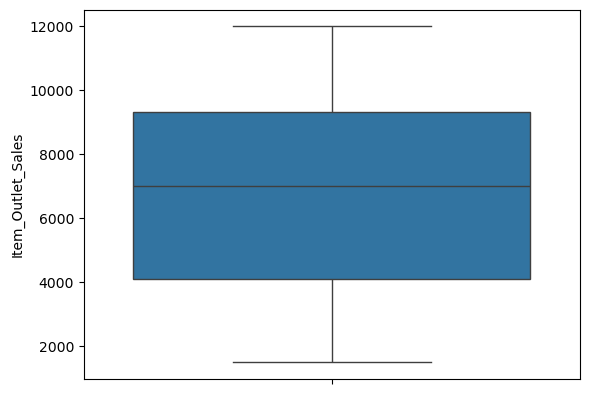

In [11]:
sns.boxplot(data.Item_Outlet_Sales) 
plt.show()


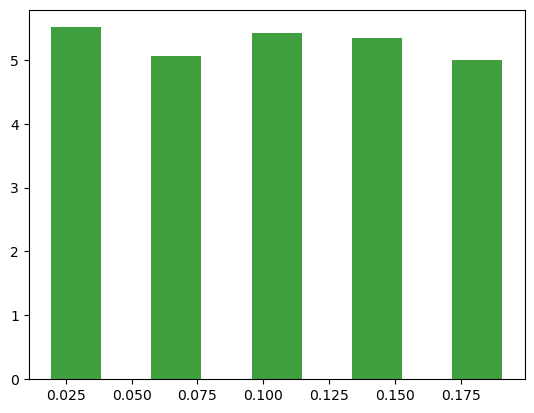

In [12]:
plt.hist(data.Item_Visibility,rwidth=.5,bins=5,density=True,facecolor='g', alpha=0.75) 
plt.show()

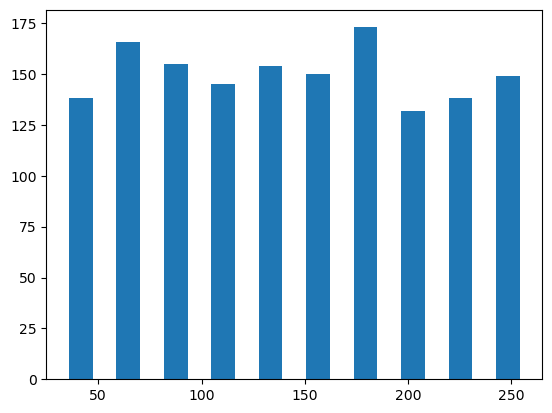

In [13]:
plt.hist(data.Item_MRP,rwidth=.5, bins = 10) 
plt.show() 

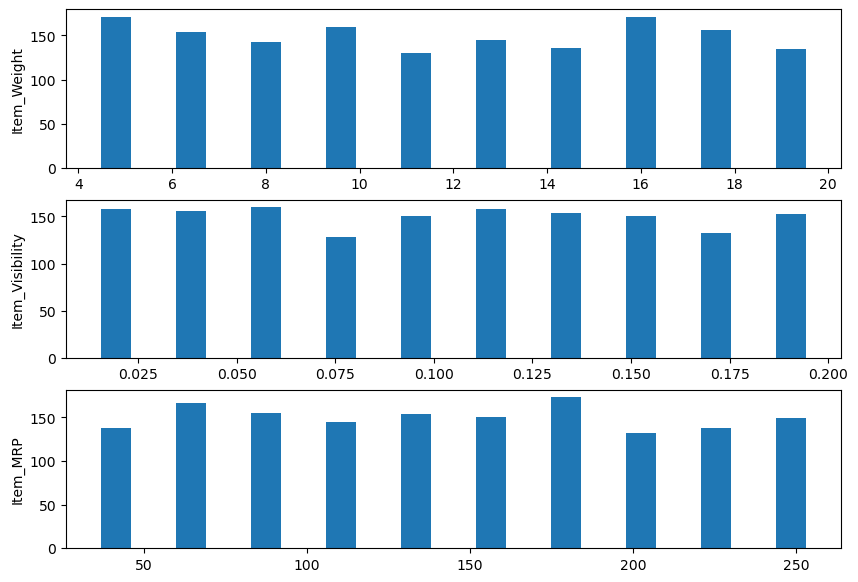

In [15]:
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    plt.hist(data[col], rwidth = .4) 
    plt.xlabel('') 
    plt.ylabel(col) 

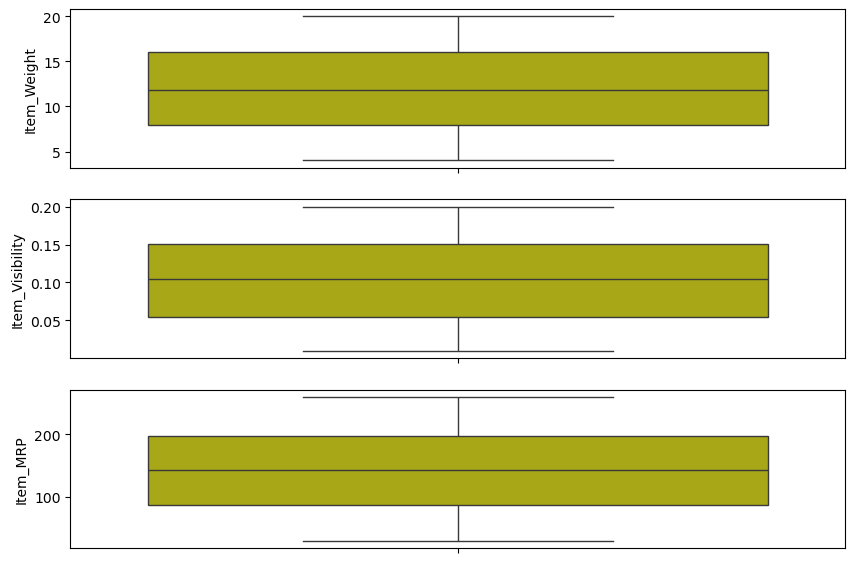

In [16]:
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    sns.boxplot(data[col], color ='y') 
    plt.xlabel('') 
    plt.ylabel(col)

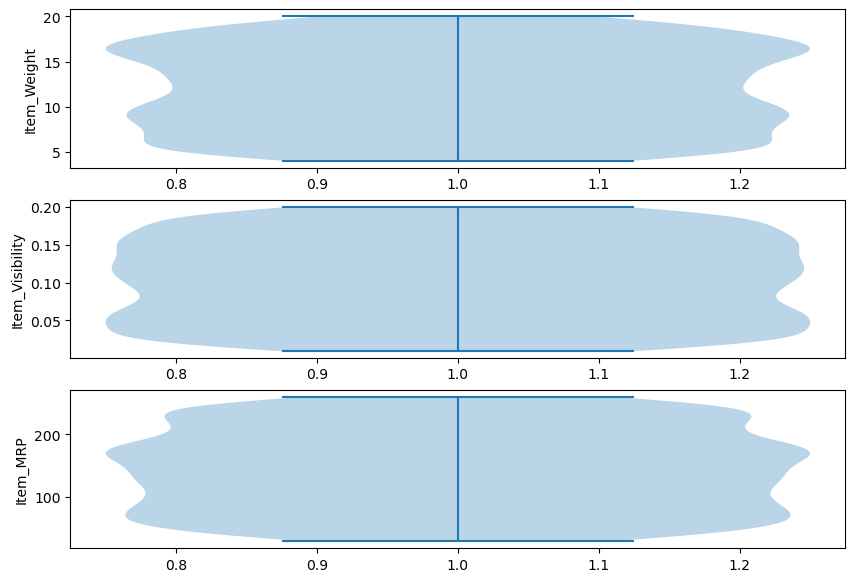

In [18]:
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    plt.violinplot(data[col]) 
    plt.xlabel('') 
    plt.ylabel(col)

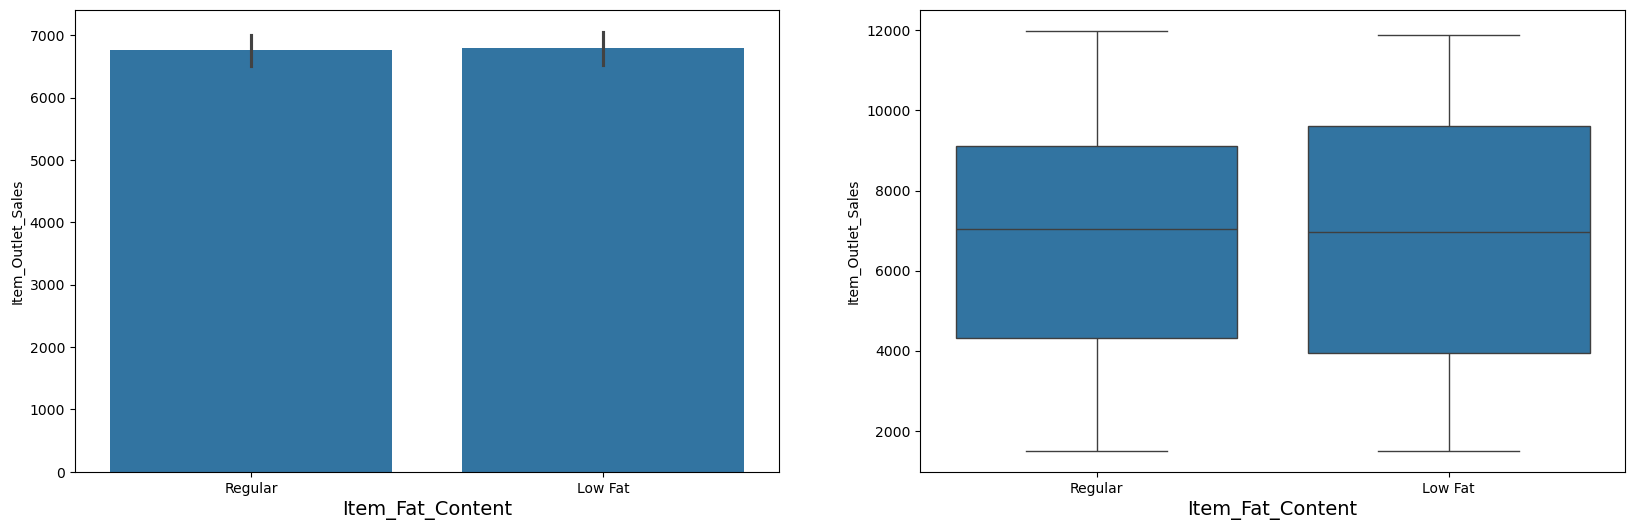

In [19]:
plt.figure(figsize=(20,6)) 
plt.subplot(1,2,1) 
sns.barplot(data=data, y='Item_Outlet_Sales', x='Item_Fat_Content') 
plt.xlabel('Item_Fat_Content', fontsize=14) 
plt.subplot(1,2,2) 
sns.boxplot(data=data, y='Item_Outlet_Sales', x='Item_Fat_Content') 
plt.xlabel('Item_Fat_Content', fontsize=14) 
plt.show()

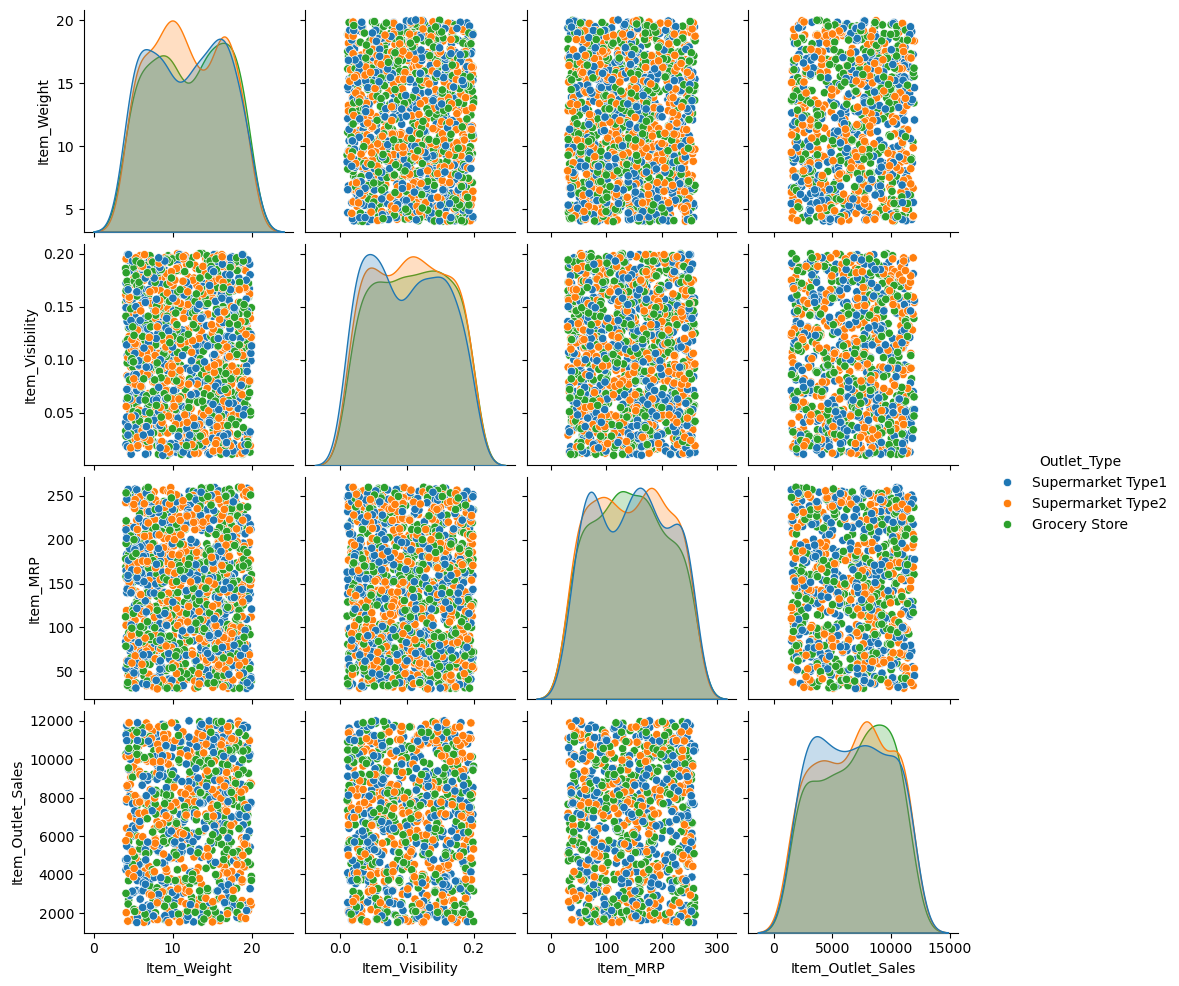

In [20]:
sns.pairplot(data.drop(columns ='Outlet_Establishment_Year'),hue='Outlet_Type') 
plt.show() 

In [21]:
round(100*(data.isna().sum())/len(data),2) 

Item_Identifier               0.00
Item_Weight                   0.00
Item_Fat_Content              0.00
Item_Visibility               0.00
Item_Type                     0.00
Item_MRP                      0.00
Outlet_Identifier             0.00
Outlet_Establishment_Year     0.00
Outlet_Size                   0.00
Outlet_Location_Type          0.00
Outlet_Type                   0.00
Item_Outlet_Sales            33.33
dtype: float64

In [22]:
data[data==0].sum()

Item_Identifier                0
Item_Weight                  0.0
Item_Fat_Content               0
Item_Visibility              0.0
Item_Type                      0
Item_MRP                     0.0
Outlet_Identifier              0
Outlet_Establishment_Year    0.0
Outlet_Size                    0
Outlet_Location_Type           0
Outlet_Type                    0
Item_Outlet_Sales            0.0
dtype: object

In [23]:
data['Item_Weight'].fillna(data["Item_Weight"].mean(), inplace=True) 
data.head() 

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,ITEM0000,16.34,Regular,0.108,Canned,247.43,OUT0,2008,Medium,Tier 3,Supermarket Type1,9578.30
1,ITEM0001,4.33,Low Fat,0.156,Fruits and Vegetables,45.46,OUT1,1994,Small,Tier 2,Supermarket Type2,11467.29
2,ITEM0002,14.14,Regular,0.048,Fruits and Vegetables,174.42,OUT2,1989,High,Tier 1,Supermarket Type2,9153.07
3,ITEM0003,15.98,Low Fat,0.107,Household,125.76,OUT3,2000,Medium,Tier 2,Supermarket Type2,1595.85
4,ITEM0004,11.98,Regular,0.178,Soft Drinks,178.44,OUT4,1988,High,Tier 2,Supermarket Type2,1866.52


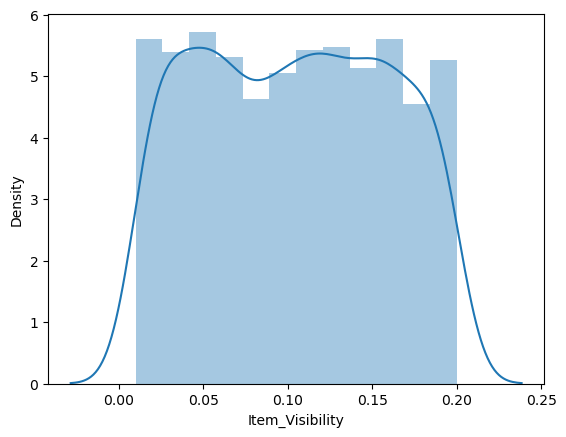

In [27]:
sns.distplot(data['Item_Visibility']) 
plt.show() 

In [30]:
test['Outlet_Size'].unique() 

array(['Medium', 'Small', 'High'], dtype=object)

In [31]:
train.nunique() 


Item_Identifier              1000
Item_Weight                   739
Item_Fat_Content                2
Item_Visibility               191
Item_Type                       8
Item_MRP                      983
Outlet_Identifier              10
Outlet_Establishment_Year      25
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     3
Item_Outlet_Sales            1000
dtype: int64

In [32]:
test.nunique() 

Item_Identifier              500
Item_Weight                  432
Item_Fat_Content               2
Item_Visibility              180
Item_Type                      8
Item_MRP                     497
Outlet_Identifier             10
Outlet_Establishment_Year     25
Outlet_Size                    3
Outlet_Location_Type           3
Outlet_Type                    3
dtype: int64

In [33]:
train.isna().sum() 

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [34]:
map1 = {"Small":1,"Medium":2,"High":3} 
train["Outlet_Size"] = train["Outlet_Size"].map(map1) 
train["Item_Weight"] = train["Item_Weight"].fillna(train.Item_Weight.mean()) 
train["Outlet_Size"] = train["Outlet_Size"].fillna(train["Outlet_Size"].median()) 
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,ITEM0000,16.34,Regular,0.108,Canned,247.43,OUT0,2008,2,Tier 3,Supermarket Type1,9578.30
1,ITEM0001,4.33,Low Fat,0.156,Fruits and Vegetables,45.46,OUT1,1994,1,Tier 2,Supermarket Type2,11467.29
2,ITEM0002,14.14,Regular,0.048,Fruits and Vegetables,174.42,OUT2,1989,3,Tier 1,Supermarket Type2,9153.07
3,ITEM0003,15.98,Low Fat,0.107,Household,125.76,OUT3,2000,2,Tier 2,Supermarket Type2,1595.85
4,ITEM0004,11.98,Regular,0.178,Soft Drinks,178.44,OUT4,1988,3,Tier 2,Supermarket Type2,1866.52


In [36]:
train.drop(labels=['Outlet_Establishment_Year'],inplace=True, axis =1) 
test.drop(labels=['Outlet_Establishment_Year'],inplace=True, axis=1) 
re_feat=["Outlet_Size","Outlet_Type","Outlet_Location_Type","Item_Fat_Content","Item_Type"] 
x=pd.get_dummies(train[re_feat]) 
train=pd.concat([train,x],axis=1) 
train.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,...,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Household,Item_Type_Meat,Item_Type_Snack Foods,Item_Type_Soft Drinks
0,ITEM0000,16.34,Regular,0.108,Canned,247.43,OUT0,2,Tier 3,Supermarket Type1,...,False,True,True,False,False,False,False,False,False,False
1,ITEM0001,4.33,Low Fat,0.156,Fruits and Vegetables,45.46,OUT1,1,Tier 2,Supermarket Type2,...,True,False,False,False,False,True,False,False,False,False
2,ITEM0002,14.14,Regular,0.048,Fruits and Vegetables,174.42,OUT2,3,Tier 1,Supermarket Type2,...,False,True,False,False,False,True,False,False,False,False
3,ITEM0003,15.98,Low Fat,0.107,Household,125.76,OUT3,2,Tier 2,Supermarket Type2,...,True,False,False,False,False,False,True,False,False,False
4,ITEM0004,11.98,Regular,0.178,Soft Drinks,178.44,OUT4,3,Tier 2,Supermarket Type2,...,False,True,False,False,False,False,False,False,False,True


In [38]:
re_feat=['Outlet_Size','Outlet_Type','Outlet_Location_Type','Item_Fat_Content',"Item_Type"] 
x1 = pd.get_dummies(test[re_feat]) 
test = pd.concat([test,x1],axis=1) 
train.drop(labels 
= 
["Outlet_Size",'Outlet_Location_Type',"Outlet_Type",'Item_Fat_Content','Outlet_Identifier','Item_Identifier',"Item_Type"],axis=1,inplace = True) 
test.drop(labels 
= 
["Outlet_Size",'Outlet_Location_Type',"Outlet_Type",'Item_Fat_Content','Outlet_Identifier','Item_Identifier',"Item_Type"],axis=1,inplace = True) 
X_train = train.drop(labels = ["Item_Outlet_Sales"],axis=1) 
y_train = train["Item_Outlet_Sales"] 
X_train.shape,y_train.shape

((1000, 19), (1000,))

In [39]:
train.head(5)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Household,Item_Type_Meat,Item_Type_Snack Foods,Item_Type_Soft Drinks
0,16.34,0.108,247.43,9578.30,False,True,False,False,False,True,False,True,True,False,False,False,False,False,False,False
1,4.33,0.156,45.46,11467.29,False,False,True,False,True,False,True,False,False,False,False,True,False,False,False,False
2,14.14,0.048,174.42,9153.07,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False
3,15.98,0.107,125.76,1595.85,False,False,True,False,True,False,True,False,False,False,False,False,True,False,False,False
4,11.98,0.178,178.44,1866.52,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True


In [40]:
y_train.head() 


0     9578.30
1    11467.29
2     9153.07
3     1595.85
4     1866.52
Name: Item_Outlet_Sales, dtype: float64

In [41]:
from sklearn import preprocessing 
x = X_train.values #returns a numpy array 
test_s = test.values 
min_max_scaler = preprocessing.MinMaxScaler() 
x_scaled_train = min_max_scaler.fit_transform(x) 
x_scaled_test = min_max_scaler.fit_transform(test_s) 
df_train = pd.DataFrame(x_scaled_train) 
df_test = pd.DataFrame(x_scaled_test) 
df_train.head() 

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.771787,0.515789,0.946053,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.018809,0.768421,0.065242,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.633856,0.200000,0.627649,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.749216,0.510526,0.415438,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.498433,0.884211,0.645181,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


predicted [6520.44785728 6503.28241748 6470.49618505 5968.44888413 6650.354249
 6635.46502125 7185.29124012 7234.8324417  7561.84955749 6559.70477932
 7303.5716035  6368.05125349 6868.7788151  6821.08315183 6520.42259873
 6910.46982851 6502.91026574 6790.37237774 6342.49643352 6588.79283778
 6759.71256445 6977.26002828 7222.84075012 6260.71111653 6981.99140957
 6915.09104846 6755.40472953 6491.61646248 6942.69006002 6437.96715972
 7242.60980416 6744.35714014 7058.93501336 6636.58031241 6531.56190953
 6895.98304813 5608.89751818 6670.90464262 6954.01403105 6198.214455
 6834.5148844  6511.93328348 6439.17291519 6689.07527124 6338.25129146
 6593.88701223 6212.68005123 7167.84945817 6528.74605874 6867.87650023
 6854.37468075 6698.98677233 6379.30162269 6874.81544677 6706.31657845
 6420.73226768 6908.66486971 6764.20037412 7324.83455981 6945.66589187
 7046.69972807 6088.02951292 7002.27365788 6340.2690412  7058.32222724
 6968.78829679 6131.07645027 6879.49238981 6444.90180011 6888.29911421


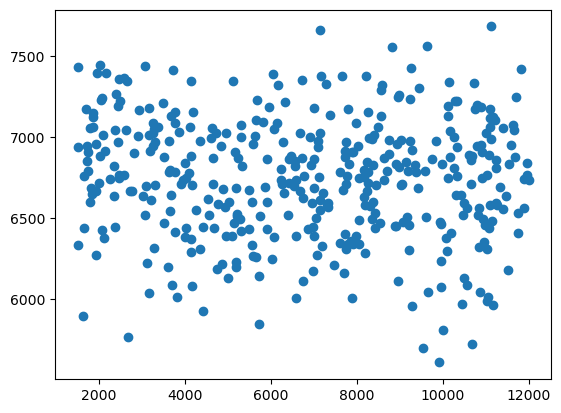

In [42]:
X_train, X_test, y_train, y_test = train_test_split(df_train, y_train, test_size=0.4) 
from sklearn.linear_model import LinearRegression as lr 
model = lr() 
model.fit(X_train,y_train) 
pred = model.predict(X_test) 
print("predicted",pred) 
plt.scatter(y_test,pred) 
plt.show()

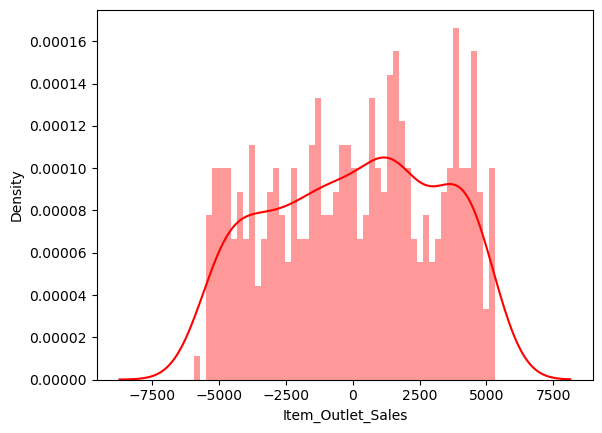

In [43]:
sns.distplot((y_test-pred),bins=50, color='r') 
plt.show() 